<a href="https://colab.research.google.com/github/raja-kumar-jha/pytorch-deep-learning-journey/blob/main/notebooks/01_pytorch_workflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PyTorch Workflow

Let's explore an example of PyTorch ene-to-end workflow

**what were covering :**

1. data (prepare and load)
2. build model
3. fitting the model to data (training)
4. making predictions and evaluting a model (inference)
5. putting it all together

In [27]:
# Import necessary libraries
import torch # PyTorch library for tensor operations and neural networks
from torch import nn # Neural network module for building models
import matplotlib.pyplot as plt # For plotting and visualization
import seaborn as sns # For enhanced data visualization

# Check the installed PyTorch version
print(torch.__version__)

2.11.0+cpu


## 1. Data preparing and loading

Data can be anything.. in machine learning.

* Excel/Google sheet
* Image of any kind
* Video(youtube has a lots of data..)
* Audio like songs or podcasts and many more things
* DNA
* Text

Machine learing is a game of two parts:
1. Get data into numerical fashion
2. Build model to learn patterns in that numerical data

In [28]:
# Create *known* parameters for our linear regression model
weight = 0.6 # The true weight (slope) of the linear relationship
bias = 0.4 # The true bias (y-intercept) of the linear relationship

# Define the range and step for our input data X
start = 0
end = 1
step = 0.02

# Generate the input data (features) X using torch.arange
# .unsqueeze(dim=1) adds a dimension to make X a column vector, which is typical for PyTorch models
X = torch.arange(start, end, step).unsqueeze(dim=1) # This is the feature (independent variable)

# Generate the output data (labels) y based on the known parameters and X
y = weight * X + bias # This is the label (dependent variable) - our ground truth

"""
Here I have created the data, the X is basically the feature of my dataset and y is the label for my data.
Now, the goal will be to predict the value of y (our true label) from the model we will implement in the next code cell.
"""

# Display the first 10 samples of X and y to inspect the generated data
X[:10], y[:10] # Here we are searching for first rows of our feature and our true label

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.4000],
         [0.4120],
         [0.4240],
         [0.4360],
         [0.4480],
         [0.4600],
         [0.4720],
         [0.4840],
         [0.4960],
         [0.5080]]))

In [29]:
# Check the total number of samples (rows) in our dataset
len(X), len(y) # here we are checking how many rows we have in total -> means how many data samples we have

(50, 50)

### Splitting data into training and test sets

In [30]:
# Create a train/test split for our dataset
# We'll use 80% of the data for training and 20% for testing
train_split = int(0.8 * len(X)) # Determine the index for the 80% split point

# Split X and y into training and testing sets
X_train, y_train = X[:train_split], y[:train_split] # This is the training sample for the learning of our model
X_test, y_test = X[train_split:], y[train_split:] # This is the dataset on which our model will be evaluated

# Display the number of samples in each split to confirm
len(X_train), len(y_train), len(X_test), len(y_test) # Here we can see how many samples are used for train and test

(40, 40, 10, 10)

In [31]:
# Define a function to visualize the training data, test data, and predictions
def plot_predictions(train_data=X_train,
                     train_labels=y_train,
                     test_data=X_test,
                     test_labels=y_test,
                     predictions=None):

  """
  Plots training data, test data, and compares predictions.
  """
  plt.figure(figsize=(6, 5)) # Create a new figure with a specified size

  # Plot the training data in blue as scatter points
  plt.scatter(train_data, train_labels, c='b', s=4, label="Training data")

  # Plot the test data in green as scatter points
  plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

  # Check if predictions are provided
  if predictions is not None:
    # Plot the predictions in red as scatter points
    plt.scatter(test_data, predictions, c='r', s=4, label="Predictions")

  # Display the legend to identify different data points
  plt.legend(prop={"size":12});

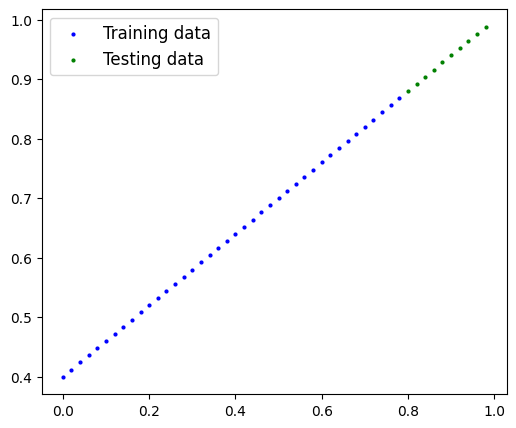

In [32]:
# Call the plot_predictions function to visualize the initial train and test data split
plot_predictions();

## 2. Building model
My first PyTorch model!

What our model does:
* Start with random values(weight & bias)
* Look at the training data and adjust the random values to better represent (or get closer to) the ideal values (the weight and bias values we used to create the data)

How does it do so?

Through two main algorithm:
1. Gradient descent
2. Backpropagation

In [33]:
# Define our Linear Regression Model class, inheriting from nn.Module
class LinearRegressionModel(nn.Module):
  # Constructor method
  def __init__(self):
    super().__init__() # Initialize the parent nn.Module class

    # Initialize model parameters (weights and bias) using nn.Parameter
    # nn.Parameter makes these tensors learnable during training.
    # torch.randn(1) creates a single random float value.
    # requires_grad=True means gradients will be computed for these parameters.
    # dtype=torch.float specifies the data type.
    self.weights = nn.Parameter(torch.randn(1,
                                            requires_grad=True, dtype= torch.float))
    self.bias = nn.Parameter(torch.randn(1,
                                         requires_grad=True, dtype=torch.float))

  # Forward method defines the computation performed by the model
  # It takes an input tensor 'x' and returns an output tensor.
  def forward(self, x:torch.Tensor) -> torch.Tensor: #<- "x" is the input data
    return self.weights * x + self.bias # This is the linear regression formula (y = mx + b)

### PyTorch model building essentials

* torch.nn - contains all of the buildings for comutational graphs(a nural network can be considered a computational graph)
* torch.nn.Parameter - what parameters should our mmodel try and learn, often a PyTorch layer from torch.nn will set these for use
* torch.nn.Module - The base class for all nural network modules, if we subclass it, we should overwrite forword()
* torch.optim - this is where the optimizers in PyTorch live, they will help with gradient decent
* def forword() - all nn.Model subclass require us to overwrite forword(), this method defines what happens in forword() comutation

### checking the contents of the Pytorch model

Now we've created a model, let's see what's inside..

So we can check our model parammeters or what's inside our model using .parameters().

In [34]:
# Set a random seed for reproducibility
torch.manual_seed(42)

# Create an instance of our LinearRegressionModel
Model_0 = LinearRegressionModel()

# Display the initial parameters (weights and bias) of the model
# These are random values before any training.
list(Model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [35]:
# Display the named parameters of the model using .state_dict()
# This provides a dictionary mapping parameter names to their current tensor values.
Model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

### Making prediction using `torch.inference_mode()`

To check our model's predictive power, let's see how well it predicts `y_test` based on `X_test`.

When we pass data through our model, it's going to run it through the forward() method.

In [36]:
# Make predictions on the test data using the untrained model
# torch.inference_mode() disables gradient calculations, which is good for inference
# as it saves memory and computation.
with torch.inference_mode():
  y_preds = Model_0(X_test) # Pass X_test through the model's forward method

# Display the predictions
y_preds

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])

In [37]:
# Display the actual true labels for the test set
y_test

tensor([[0.8800],
        [0.8920],
        [0.9040],
        [0.9160],
        [0.9280],
        [0.9400],
        [0.9520],
        [0.9640],
        [0.9760],
        [0.9880]])

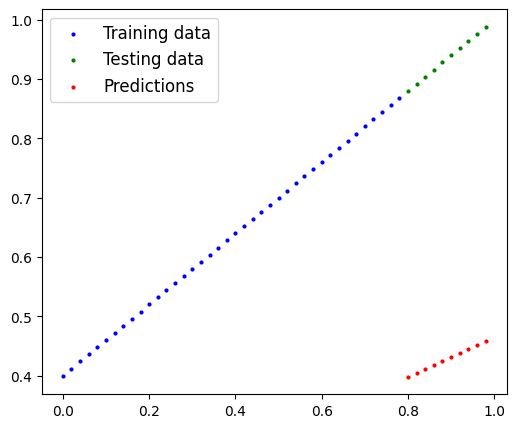

In [38]:
# Plot the predictions made by the untrained model against the actual test data
# This helps visualize how far off the initial predictions are.
plot_predictions(predictions=y_preds)

## Train model
The whole idea of training is for a model to move from some "unknown" parameters(these may be random) to **Known** parameters.

Or in other words from a poor representation of the data to a better representation of data.

One way to measure how poor or how wrong your models predictions are is to use a loss function.

* Note: Loss function may also be called cost function or criterion in different areas.

Things we need to train:
* Loss function: A function to measure how wrong our model's predictions are to the ideal outputs. Lower the loss better the result.

* Optimizer: An optimisizer updates the model's parameters to minimize the loss.

for exam, suppose our model has:
` w = 5`

The loss function tells us that the corrent value of w isn't good.

The optimizer might change it

In [39]:
# Display the current state (parameters) of Model_0 before training begins
Model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [40]:
# Setup a Loss Function (also known as criterion or cost function)
# nn.L1Loss() calculates the Mean Absolute Error (MAE) between predictions and actual labels.
# It measures the average magnitude of errors without considering their direction.
loss_fn = nn.L1Loss()

# Setup an Optimizer (Stochastic Gradient Descent - SGD)
# The optimizer is responsible for updating the model's parameters based on the gradients of the loss.
# params=Model_0.parameters() tells the optimizer which parameters to update.
# lr=0.01 (learning rate) is a hyperparameter that controls the step size during optimization.
# A smaller LR means smaller steps, a larger LR means larger steps.
optimizer = torch.optim.SGD(params=Model_0.parameters(),
                            lr=0.01) # lr = learning rate -> possibly the most important hyperparameter

### Building a training loop (and a testing loop) in PyTorch

A couple of things we need in a training loop:

0. Loop through the data
1. Forword pass (this involves data moving through our model's `forward()` functions) to make predictions on data - also called forward propagation.
2. Calculate the loss (compare forward pass predictions to ground truth labels)
3. Optimizer zero grad
4. Loss backward - move backwords through the network to calculate the gradients of each of the parameters of our model with respect to the loss
5. Optimizer step - use the optimizer to adjust our model's parameters to try and improve the loss




In [41]:
# Set a random seed for reproducibility
torch.manual_seed(42)

# Define the number of epochs (how many times the model will go through the entire dataset)
# An epoch is one full pass over the entire training dataset.
epochs = 200 # This is a hyperparameter because we set it.

# Lists to track performance metrics over epochs
epoch_count = []       # Stores epoch numbers
loss_values = []       # Stores training loss for each epoch
test_loss_values = []  # Stores test loss for each epoch

# 0. Loop through the data for a specified number of epochs
for epoch in range(epochs):
  # Set the model to training mode
  # Model.train() sets all parameters that require gradients to require gradients and enables specific layers (e.g., Dropout, BatchNorm) for training behavior.
  Model_0.train()

  # 1. Forward pass: data moves through our model's forward() function to make predictions
  y_pred = Model_0(X_train)

  # 2. Calculate the loss: compare forward pass predictions to ground truth labels
  loss = loss_fn(y_pred, y_train)

  # 3. Optimizer zero_grad(): Zero the gradients accumulated from the previous step
  # By default, gradients accumulate, so we must zero them out before a new backward pass.
  optimizer.zero_grad()

  # 4. Perform backpropagation: calculate gradients of each parameter with respect to the loss
  # This computes d(loss)/d(param) for every parameter 'param' in the model.
  loss.backward()

  # 5. Optimizer step(): Update the model's parameters using the computed gradients
  # This performs the actual weight updates (e.g., Gradient Descent step).
  optimizer.step() # By default, how the optimizer changes will accumulate through the loop so we have to zero them above in step 3 for the next iterations of the loop

  # Testing phase
  Model_0.eval() # Set the model to evaluation mode
  # Model.eval() turns off gradient tracking and sets specific layers (e.g., Dropout, BatchNorm) to evaluation behavior.
  with torch.inference_mode(): # Disable gradient calculations for efficiency during evaluation
    # Do the forward pass on the test data
    test_pred = Model_0(X_test)
    # Calculate the test loss
    test_loss = loss_fn(test_pred, y_test)

    # Print out progress every 10 epochs
    if epoch % 10 == 0:
      epoch_count.append(epoch)
      # Detach losses from the computation graph before storing to avoid memory issues
      loss_values.append(loss.detach().numpy()) # Convert to NumPy for plotting if needed
      test_loss_values.append(test_loss.detach().numpy()) # Convert to NumPy for plotting if needed
      print(f"Epoch: {epoch} | Loss: {loss:.4f} | Test loss: {test_loss:.4f}") # Format loss values for readability
      # Print out model's current state (weights and bias)
      print(f"Model state_dict: {Model_0.state_dict()}")

Epoch: 0 | Loss: 0.3739 | Test loss: 0.4921
Model state_dict: OrderedDict({'weights': tensor([0.3406]), 'bias': tensor([0.1388])})
Epoch: 10 | Loss: 0.2587 | Test loss: 0.3574
Model state_dict: OrderedDict({'weights': tensor([0.3796]), 'bias': tensor([0.2388])})
Epoch: 20 | Loss: 0.1435 | Test loss: 0.2226
Model state_dict: OrderedDict({'weights': tensor([0.4186]), 'bias': tensor([0.3388])})
Epoch: 30 | Loss: 0.0385 | Test loss: 0.0974
Model state_dict: OrderedDict({'weights': tensor([0.4571]), 'bias': tensor([0.4298])})
Epoch: 40 | Loss: 0.0239 | Test loss: 0.0576
Model state_dict: OrderedDict({'weights': tensor([0.4827]), 'bias': tensor([0.4468])})
Epoch: 50 | Loss: 0.0203 | Test loss: 0.0466
Model state_dict: OrderedDict({'weights': tensor([0.5007]), 'bias': tensor([0.4418])})
Epoch: 60 | Loss: 0.0169 | Test loss: 0.0390
Model state_dict: OrderedDict({'weights': tensor([0.5176]), 'bias': tensor([0.4343])})
Epoch: 70 | Loss: 0.0135 | Test loss: 0.0307
Model state_dict: OrderedDict({'

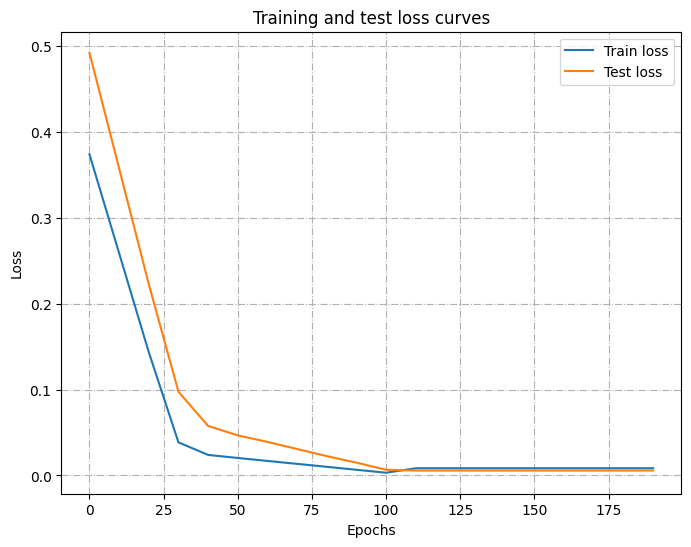

In [50]:
import numpy as np # Import numpy for potential array operations, though torch.tensor().numpy() is used directly.

# Plot the training and test loss curves over epochs
plt.figure(figsize=(8, 6)) # Create a figure with a good size
plt.plot(epoch_count, np.array(loss_values), label="Train loss") # Plot training loss
plt.plot(epoch_count, np.array(test_loss_values), label="Test loss") # Plot test loss
plt.title("Training and test loss curves") # Set the plot title
plt.ylabel("Loss") # Set the y-axis label
plt.xlabel("Epochs") # Set the x-axis label
plt.legend() # Display the legend to distinguish lines
plt.grid(True, linestyle='-.') # Add a grid for better readability
plt.show() # Display the plot

In [43]:
# Display the original true weight and bias values used to generate the data
# This allows us to compare them with the model's learned parameters.
weight, bias

(0.6, 0.4)

In [44]:
# Make predictions on the test data using the *trained* Model_0
# We use torch.inference_mode() again for efficiency during prediction.
with torch.inference_mode():
  y_pred_new = Model_0(X_test) # Pass X_test through the trained model

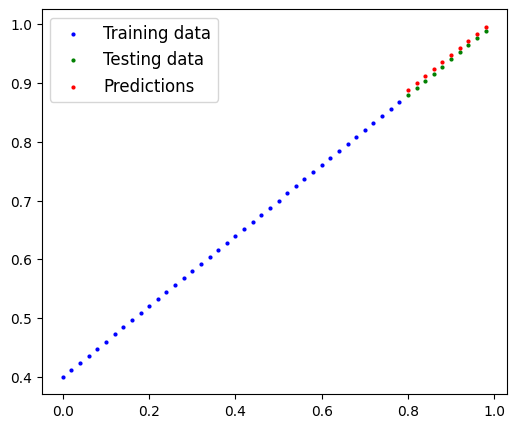

In [45]:
# Plot the predictions made by the *trained* model against the actual test data and training data
# This visualization will show how well the trained model's predictions align with the true test labels.
plot_predictions(predictions=y_pred_new)